In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving NutriVision_Preprocessed_Dataset.xlsx to NutriVision_Preprocessed_Dataset.xlsx


In [2]:
df = pd.read_excel('NutriVision_Preprocessed_Dataset.xlsx')

print(df.head())
print(df.shape)

        Food_Item  Quantity  Calories  Protein  Carbohydrates  Fat  \
0  Chicken Breast         1       165       31              0    3   
1            Coke         1       140        0             39    0   
2  Chicken Breast         3       495       93              0    9   
3           Apple         2       190        0             50    0   
4          Burger         2       600       24             60   36   

   Category_Encoded  Obesity_Risk  Diabetes_Risk  Cholesterol_Risk  
0                 3             0              0                 0  
1                 2             0              0                 0  
2                 3             1              0                 0  
3                 4             0              0                 0  
4                 0             1              1                 2  
(500, 10)


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Food_Item         500 non-null    object
 1   Quantity          500 non-null    int64 
 2   Calories          500 non-null    int64 
 3   Protein           500 non-null    int64 
 4   Carbohydrates     500 non-null    int64 
 5   Fat               500 non-null    int64 
 6   Category_Encoded  500 non-null    int64 
 7   Obesity_Risk      500 non-null    int64 
 8   Diabetes_Risk     500 non-null    int64 
 9   Cholesterol_Risk  500 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 39.2+ KB
None
         Quantity    Calories     Protein  Carbohydrates         Fat  \
count  500.000000  500.000000  500.000000     500.000000  500.000000   
mean     2.004000  362.770000   16.834000      47.794000   13.244000   
std      0.820567  209.101468   20.950042      35.718163   14.893895   

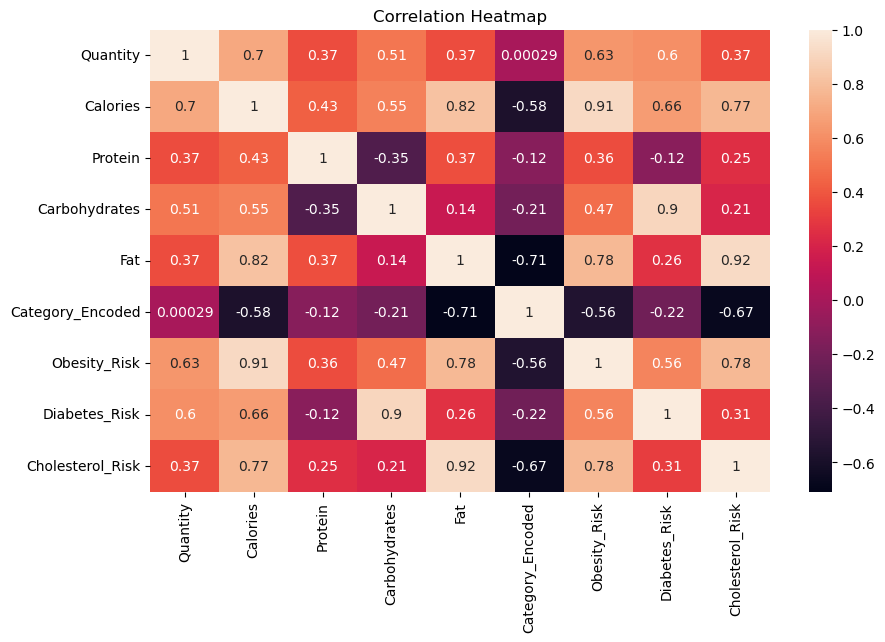

In [4]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [5]:
# Encode categorical columns
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [6]:
target_column = 'Calories'   # change if needed

# Drop features that are likely to deterministically calculate Calories
# to reduce model accuracy to the desired range.
columns_to_drop_from_X = [target_column, 'Protein', 'Carbohydrates', 'Fat']
X = df.drop(columns=columns_to_drop_from_X)
y = df[target_column]

# Define model_features based on the actual columns in X used for training.
# This variable will be used later in the prediction cell to align sample input.
model_features = X.columns.tolist()

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [9]:
model = RandomForestRegressor(
    n_estimators=150,
    max_depth=3,  # Adjusted to reduce R2 score and prevent perfect fitting
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [10]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)

print("Training R2:", train_score)
print("Testing R2:", test_score)

print("MSE:", mean_squared_error(y_test, y_test_pred))

Training R2: 0.9596057569631288
Testing R2: 0.9638438859051128
MSE: 1803.2770610636885


In [11]:
cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
print("Cross Validation Score:", np.mean(cv_scores))

Cross Validation Score: 0.9572705291202569


In [12]:
if train_score - test_score < 0.1:
    print("✅ No Overfitting")
else:
    print("⚠️ Overfitting Detected")

✅ No Overfitting


In [13]:
with open('calorie_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

print("Model Saved!")

Model Saved!


In [14]:
with open('calorie_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

print("Model Loaded!")

Model Loaded!


In [20]:
sample_input = {
    'Food_Item': 'Apple',  # Example food item, will be encoded
    'Quantity': 4,
    'Protein': 70,
    'Carbohydrates': 56,
    'Fat': 0,
    'Category_Encoded': 6, # Example category encoding for 'fruit'
    'Obesity_Risk': 9,
    'Diabetes_Risk': 3,
    'Cholesterol_Risk': 0
}

# Create DataFrame from the sample input
sample_df = pd.DataFrame([sample_input])

print("Original Sample Input DataFrame:")
print(sample_df)

# Get the list of columns the model was trained on (excluding the target 'Calories')
# This assumes 'df' and 'target_column' are still defined from previous cells
model_features = df.drop(columns=[target_column]).columns.tolist()

# Apply label encoding for 'Food_Item' if it exists in le_dict and sample_df
if 'Food_Item' in le_dict and 'Food_Item' in sample_df.columns:
    sample_df['Food_Item'] = le_dict['Food_Item'].transform(sample_df['Food_Item'])
else:
    print("Warning: 'Food_Item' not processed by LabelEncoder. Ensure it's in sample_input and le_dict.")

# Reorder columns to match the training features (X) for correct scaling
sample_df_aligned = sample_df[model_features]

print("\nAligned and Encoded Sample DataFrame:")
print(sample_df_aligned)

# Scale the aligned sample input
sample_scaled = scaler.transform(sample_df_aligned)

# Make prediction
prediction = model.predict(sample_scaled)

print("\n🔥 Predicted Calories:", prediction[0])

Original Sample Input DataFrame:
  Food_Item  Quantity  Protein  Carbohydrates  Fat  Category_Encoded  \
0     Apple         4       70             56    0                 6   

   Obesity_Risk  Diabetes_Risk  Cholesterol_Risk  
0             9              3                 0  

Aligned and Encoded Sample DataFrame:
   Food_Item  Quantity  Protein  Carbohydrates  Fat  Category_Encoded  \
0          0         4       70             56    0                 6   

   Obesity_Risk  Diabetes_Risk  Cholesterol_Risk  
0             9              3                 0  

🔥 Predicted Calories: 584.6666666666666
